In [5]:
import torch
print(f"GPU Available: {torch.cuda.is_available()}")
print(f"GPU Name: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

GPU Available: True
GPU Name: Tesla T4


In [9]:
import nltk, networkx, joblib
print("✅ All installed correctly!")


✅ All installed correctly!


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# NLP and Text Processing
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords

# Download NLTK data
import nltk
nltk_data_dir = "/kaggle/working/nltk_data"

# Download data safely to a writable location
nltk.download('punkt', download_dir=nltk_data_dir, quiet=True)
nltk.download('stopwords', download_dir=nltk_data_dir, quiet=True)

# Add the custom path to NLTK
nltk.data.path.append(nltk_data_dir)


# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score, classification_report, confusion_matrix

# Deep Learning - Transformers
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding  # For dynamic padding (faster)
)
from datasets import Dataset
import torch

# Graph and Network Analysis
import networkx as nx

# Utilities
import joblib
import os
from collections import Counter
from typing import Dict, List, Tuple
import json

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [16]:
class FastConfig:
    """Optimized configuration for fast training"""
    
    # ⚡ SPEED OPTIMIZATION: Use DistilBERT (much faster than DeBERTa)
    MODEL_NAME = "distilbert-base-uncased"  # 6x faster than DeBERTa!
    MAX_LENGTH = 256  # Reduced from 512 (most segments are < 256 tokens anyway)
    
    # Label Definitions (same as before)
    LABEL_LIST = [
        'Claim', 
        'Evidence', 
        'Lead', 
        'Position', 
        'Counterclaim', 
        'Rebuttal', 
        'Concluding Statement'
    ]
    NUM_LABELS = len(LABEL_LIST)
    LABEL_TO_ID = {label: i for i, label in enumerate(LABEL_LIST)}
    ID_TO_LABEL = {i: label for i, label in enumerate(LABEL_LIST)}
    
    # ⚡ SPEED OPTIMIZATION: Faster training parameters
    LEARNING_RATE = 3e-5  # Slightly higher for faster convergence
    BATCH_SIZE = 16  # Increased from 8 (faster on GPU)
    NUM_EPOCHS = 2  # Reduced from 3 (usually enough)
    WEIGHT_DECAY = 0.01
    GRADIENT_ACCUMULATION_STEPS = 2  # Effective batch size = 16 * 2 = 32
    
    # Data configuration
    TRAIN_RATIO = 0.70
    VAL_RATIO = 0.15
    TEST_RATIO = 0.15
    
    # ⚡ OPTIONAL: Train on subset for even faster training
    USE_SUBSET = False  # Set to True for 15-minute training!
    SUBSET_FRACTION = 0.5  # Use 50% of data if USE_SUBSET=True
    
    # File Paths
    DATA_PATH = '/kaggle/input/corpus-dataset/persuade_corpus_1.0.csv'
    MODEL_OUTPUT_DIR = './fast_model_results'
    QUALITY_MODEL_PATH = 'fast_quality_model.pkl'
    
    # Random Seed
    RANDOM_SEED = 42
    
    # ⚡ Training optimizations
    FP16 = torch.cuda.is_available()  # Use mixed precision if GPU available
    DATALOADER_NUM_WORKERS = 2  # Parallel data loading

config = FastConfig()

print(f"\n⚡ FAST CONFIG LOADED:")
print(f"   Model: {config.MODEL_NAME} (6x faster than DeBERTa)")
print(f"   Epochs: {config.NUM_EPOCHS} (reduced from 3)")
print(f"   Batch size: {config.BATCH_SIZE} (increased from 8)")
print(f"   Max length: {config.MAX_LENGTH} (reduced from 512)")
print(f"   Expected time: 30-45 minutes")
if config.USE_SUBSET:
    print(f"   ⚡ SUBSET MODE: Using {config.SUBSET_FRACTION*100}% of data (15 min)")



⚡ FAST CONFIG LOADED:
   Model: distilbert-base-uncased (6x faster than DeBERTa)
   Epochs: 2 (reduced from 3)
   Batch size: 16 (increased from 8)
   Max length: 256 (reduced from 512)
   Expected time: 30-45 minutes


In [17]:
# DATA LOADING

print("LOADING DATA FROM CSV")

try:
    df_raw = pd.read_csv(config.DATA_PATH, encoding='utf-8')
    print(f" Successfully loaded {len(df_raw):,} rows")
except FileNotFoundError:
    print(f" Error: File '{config.DATA_PATH}' not found!")

print(f"\nDataset Shape: {df_raw.shape}")
print(f"Columns: {df_raw.columns.tolist()}")

LOADING DATA FROM CSV
 Successfully loaded 285,383 rows

Dataset Shape: (285383, 9)
Columns: ['essay_id_comp', 'competition_set', 'full_text', 'discourse_id', 'discourse_start', 'discourse_end', 'discourse_text', 'discourse_type', 'discourse_type_num']


In [18]:
def clean_and_prepare_data(df: pd.DataFrame, min_essay_words: int = 300) -> pd.DataFrame:
    print("DATA CLEANING AND PREPROCESSING")

    df_clean = df.copy()
    
    # Fix 1: Ensure 'text' column exists (map from 'discourse_text' if needed)
    if 'text' not in df_clean.columns and 'discourse_text' in df_clean.columns:
        df_clean['text'] = df_clean['discourse_text']
        print("✅ Mapped 'discourse_text' to 'text' column")
    
    # Fix 2: Ensure 'discourse_type' exists
    if 'discourse_type' not in df_clean.columns:
        raise ValueError("'discourse_type' column not found in data!")
    
    # Keep only necessary columns
    required_cols = ['text', 'discourse_type']
    optional_cols = ['essay_id', 'discourse_id', 'discourse_effectiveness', 'essay_id_comp', 'full_text']
    
    # Find which optional columns exist
    available_cols = required_cols + [col for col in optional_cols if col in df_clean.columns]
    df_clean = df_clean[available_cols]
    
    # Ensure essay_id exists 
    if 'essay_id' not in df_clean.columns and 'essay_id_comp' in df_clean.columns:
        df_clean['essay_id'] = df_clean['essay_id_comp']
    
    print(f"\nBefore cleaning: {len(df_clean):,} rows")
    
    # Remove missing values
    df_clean = df_clean.dropna(subset=['text', 'discourse_type'])
    print(f"After removing missing values: {len(df_clean):,} rows")
    
    # Remove duplicates
    df_clean = df_clean.drop_duplicates()
    print(f"After removing duplicates: {len(df_clean):,} rows")
 
    #  FILTER OUT SHORT ESSAYS 
    if 'essay_id' in df_clean.columns:
        print(f"\nFILTERING ESSAYS BY LENGTH (Minimum: {min_essay_words} words)")
        
        # Calculate total word count per essay
        if 'full_text' in df_clean.columns:
            # If full essay text is available, use it
            essay_word_counts = df_clean.groupby('essay_id')['full_text'].first().str.split().str.len()
        else:
            # Otherwise, sum word counts of all segments
            essay_word_counts = df_clean.groupby('essay_id')['text'].apply(
                lambda x: sum(str(text).split().__len__() for text in x)
            )
        
        # Get essays that meet minimum length
        valid_essays = essay_word_counts[essay_word_counts >= min_essay_words].index
        
        print(f"   Total essays before filter: {df_clean['essay_id'].nunique():,}")
        print(f"   Essays meeting {min_essay_words}+ word requirement: {len(valid_essays):,}")
        print(f"   Essays being removed: {df_clean['essay_id'].nunique() - len(valid_essays):,}")
        
        # Show word count distribution
        print(f"\n   Essay Length Distribution:")
        print(f"   Min: {essay_word_counts.min():.0f} words")
        print(f"   25th percentile: {essay_word_counts.quantile(0.25):.0f} words")
        print(f"   Median: {essay_word_counts.median():.0f} words")
        print(f"   75th percentile: {essay_word_counts.quantile(0.75):.0f} words")
        print(f"   Max: {essay_word_counts.max():.0f} words")
        
        # Filter the dataframe
        rows_before = len(df_clean)
        df_clean = df_clean[df_clean['essay_id'].isin(valid_essays)]
        rows_removed = rows_before - len(df_clean)
        
        print(f"\n   Rows before filter: {rows_before:,}")
        print(f"   Rows after filter: {len(df_clean):,}")
        print(f"   Rows removed: {rows_removed:,} ({rows_removed/rows_before*100:.1f}%)")
        print(f"   Short essays filtered successfully!")
    else:
        print(f"\nNo essay_id column found - skipping essay-level filtering")
        print(f"   (Will only filter individual segments)")
    
    # Remove very short SEGMENTS (less than 10 characters)
    df_clean['text_length'] = df_clean['text'].astype(str).str.len()
    df_clean = df_clean[df_clean['text_length'] > 10]
    print(f"\nAfter removing very short segments: {len(df_clean):,} rows")
    
    # Add word count
    df_clean['word_count'] = df_clean['text'].astype(str).str.split().str.len()
    
    # Remove outliers (texts that are too long - likely errors)
    Q1 = df_clean['text_length'].quantile(0.25)
    Q3 = df_clean['text_length'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 3 * IQR
    upper_bound = Q3 + 3 * IQR
    
    df_clean = df_clean[
        (df_clean['text_length'] >= lower_bound) & 
        (df_clean['text_length'] <= upper_bound)
    ]
    print(f"After removing outliers: {len(df_clean):,} rows")
    
    # Reset index
    df_clean = df_clean.reset_index(drop=True)
    
    print(f"\nCleaning complete! Final dataset: {len(df_clean):,} rows")
    if 'essay_id' in df_clean.columns:
        print(f"   Final essay count: {df_clean['essay_id'].nunique():,} essays")
    print(f"\nDiscourse type distribution:")
    print(df_clean['discourse_type'].value_counts())
    
    return df_clean

df_clean = clean_and_prepare_data(df_raw, min_essay_words=300) 

DATA CLEANING AND PREPROCESSING
✅ Mapped 'discourse_text' to 'text' column

Before cleaning: 285,383 rows
After removing missing values: 285,383 rows
After removing duplicates: 285,383 rows

FILTERING ESSAYS BY LENGTH (Minimum: 300 words)
   Total essays before filter: 25,996
   Essays meeting 300+ word requirement: 17,519
   Essays being removed: 8,477

   Essay Length Distribution:
   Min: 143 words
   25th percentile: 268 words
   Median: 373 words
   75th percentile: 509 words
   Max: 1656 words

   Rows before filter: 285,383
   Rows after filter: 216,326
   Rows removed: 69,057 (24.2%)
   Short essays filtered successfully!

After removing very short segments: 202,045 rows
After removing outliers: 199,983 rows

Cleaning complete! Final dataset: 199,983 rows
   Final essay count: 17,463 essays

Discourse type distribution:
discourse_type
Claim                   63540
Evidence                55136
Unannotated             22185
Position                17420
Concluding Statement    1

In [19]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Create advanced text and structural features:
    - Sentence count
    - Average word length
    - Uppercase ratio
    - Position features (if essay_id exists)
    """
    print("FEATURE ENGINEERING")
    df_fe = df.copy()
    
    # Text-based features
    print("Creating text-based features...")
    df_fe['sentence_count'] = df_fe['text'].apply(
        lambda x: len(sent_tokenize(str(x)))
    )
    df_fe['avg_word_length'] = df_fe['text_length'] / df_fe['word_count']
    df_fe['uppercase_ratio'] = df_fe['text'].apply(
        lambda x: sum(1 for c in str(x) if c.isupper()) / len(str(x)) 
        if len(str(x)) > 0 else 0
    )
    
    # Position features (only if essay_id exists)
    if 'essay_id' in df_fe.columns:
        print("Creating position features...")
        df_fe['component_position'] = df_fe.groupby('essay_id').cumcount() + 1
        df_fe['total_components'] = df_fe.groupby('essay_id')['text'].transform('count')
        df_fe['relative_position'] = df_fe['component_position'] / df_fe['total_components']
    
    print(f"✅ Feature engineering complete! Total features: {df_fe.shape[1]}")
    return df_fe

df_features = engineer_features(df_clean)

FEATURE ENGINEERING
Creating text-based features...
Creating position features...
✅ Feature engineering complete! Total features: 14


In [20]:
def split_data_by_essay(df: pd.DataFrame, config: FastConfig) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:

    print("TRAIN/VALIDATION/TEST SPLIT")

if 'essay_id' in df_clean.columns:
    unique_essays = df_clean['essay_id'].unique()
    
    train_essays, temp_essays = train_test_split(
        unique_essays, test_size=0.30, random_state=config.RANDOM_SEED
    )
    val_essays, test_essays = train_test_split(
        temp_essays, test_size=0.50, random_state=config.RANDOM_SEED
    )
    
    train_df = df_clean[df_clean['essay_id'].isin(train_essays)].copy()
    val_df = df_clean[df_clean['essay_id'].isin(val_essays)].copy()
    test_df = df_clean[df_clean['essay_id'].isin(test_essays)].copy()
else:
    train_df, temp_df = train_test_split(df_clean, test_size=0.30, random_state=config.RANDOM_SEED)
    val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=config.RANDOM_SEED)

print(f"Train: {len(train_df):,} samples")
print(f"Val:   {len(val_df):,} samples")
print(f"Test:  {len(test_df):,} samples")

# ⚡ OPTIONAL: Use subset for ultra-fast training
if config.USE_SUBSET:
    print(f"\n⚡ SUBSET MODE: Using {config.SUBSET_FRACTION*100}% of training data")
    train_df = train_df.sample(frac=config.SUBSET_FRACTION, random_state=config.RANDOM_SEED)
    print(f"   Reduced train size: {len(train_df):,} samples")


Train: 139,796 samples
Val:   29,952 samples
Test:  30,235 samples


In [21]:
def prepare_for_transformers(train_df: pd.DataFrame, 
                             val_df: pd.DataFrame, 
                             test_df: pd.DataFrame,
                             config: FastConfig) -> Tuple[Dataset, Dataset, Dataset]:
    """
    Convert DataFrames to Hugging Face Dataset format:
    - Map discourse_type strings to numerical labels
    - Handle missing/invalid labels
    - Convert to HF Dataset
    """
    print("PREPARING DATA FOR TRANSFORMER MODEL")

    def prepare_single_df(df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()
        df = df.reset_index(drop=True)
        
        # Ensure discourse_type is string
        df['discourse_type'] = df['discourse_type'].astype(str)
        
        # Map to numerical labels
        df['labels'] = df['discourse_type'].map(config.LABEL_TO_ID)
        
        # Remove rows with unmapped labels
        df = df.dropna(subset=['labels'])
        df['labels'] = df['labels'].astype(int)
        
        # Keep only necessary columns
        df = df[['text', 'discourse_type', 'labels']]
        
        return df
    
    # Prepare all splits
    train_prepared = prepare_single_df(train_df)
    val_prepared = prepare_single_df(val_df)
    test_prepared = prepare_single_df(test_df)
    
    print(f"Train samples: {len(train_prepared):,}")
    print(f"Val samples:   {len(val_prepared):,}")
    print(f"Test samples:  {len(test_prepared):,}")
    
    # Convert to HF Dataset
    hf_train = Dataset.from_pandas(train_prepared)
    hf_val = Dataset.from_pandas(val_prepared)
    hf_test = Dataset.from_pandas(test_prepared)
    
    print("\n✅ Data prepared for transformers")
    return hf_train, hf_val, hf_test

hf_train_ds, hf_val_ds, hf_test_ds = prepare_for_transformers(train_df, val_df, test_df, config)

PREPARING DATA FOR TRANSFORMER MODEL
Train samples: 124,283
Val samples:   26,680
Test samples:  26,835

✅ Data prepared for transformers


In [22]:
def tokenize_datasets(train_ds: Dataset, val_ds: Dataset, test_ds: Dataset, config: FastConfig) -> Tuple[Dataset, Dataset, Dataset]:
    """Tokenize all datasets using the transformer's tokenizer."""
    print("TOKENIZING DATA")

    # Load tokenizer
    tokenizer = AutoTokenizer.from_pretrained(config.MODEL_NAME)
    
    def tokenize_function(examples):
        return tokenizer(
            examples['text'],
            padding='max_length',
            truncation=True,
            max_length=config.MAX_LENGTH
        )
    
    # Apply tokenization
    print("Tokenizing train set...")
    tokenized_train = train_ds.map(tokenize_function, batched=True)
    
    print("Tokenizing validation set...")
    tokenized_val = val_ds.map(tokenize_function, batched=True)
    
    print("Tokenizing test set...")
    tokenized_test = test_ds.map(tokenize_function, batched=True)
    
    # Remove unnecessary columns and set format
    cols_to_remove = ['text', 'discourse_type']
    final_train = tokenized_train.remove_columns(cols_to_remove).with_format('torch')
    final_val = tokenized_val.remove_columns(cols_to_remove).with_format('torch')
    final_test = tokenized_test.remove_columns(cols_to_remove).with_format('torch')
    
    print("✅ Tokenization complete!")
    
    return final_train, final_val, final_test, tokenizer

final_train_ds, final_val_ds, final_test_ds, tokenizer = tokenize_datasets(
    hf_train_ds, hf_val_ds, hf_test_ds, config
)

TOKENIZING DATA


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

Tokenizing validation set...


Map:   0%|          | 0/26680 [00:00<?, ? examples/s]

Tokenizing test set...


Map:   0%|          | 0/26835 [00:00<?, ? examples/s]

✅ Tokenization complete!


In [23]:
!pip install evaluate
import evaluate



def train_discourse_classifier(train_ds: Dataset, val_ds: Dataset, tokenizer, config: FastConfig):
    """Train the discourse type classification model (Stage 1)."""
    print("STAGE 1: TRAINING DISCOURSE TYPE CLASSIFIER")
 
    # Load model
    print(f"Loading {config.MODEL_NAME}...")
    model = AutoModelForSequenceClassification.from_pretrained(
        config.MODEL_NAME,
        num_labels=config.NUM_LABELS,
        id2label=config.ID_TO_LABEL,
        label2id=config.LABEL_TO_ID
    )
    
    # Define metrics
    import evaluate
    metric = evaluate.load("f1")
    
    def compute_metrics(eval_pred):
        predictions, labels = eval_pred
        predictions = np.argmax(predictions, axis=1)
        return metric.compute(
            predictions=predictions,
            references=labels,
            average='macro'
        )
    
    # Training arguments
    training_args = TrainingArguments(
        output_dir=config.MODEL_OUTPUT_DIR,
        learning_rate=config.LEARNING_RATE,
        per_device_train_batch_size=config.BATCH_SIZE,
        per_device_eval_batch_size=config.BATCH_SIZE,
        num_train_epochs=config.NUM_EPOCHS,
        weight_decay=config.WEIGHT_DECAY,
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='f1',
        report_to='none',
        logging_steps=100
    )
    
    # Initialize Trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        tokenizer=tokenizer,
        compute_metrics=compute_metrics
    )
    
    # Train!
    print("\n🚀 Starting training...")
    trainer.train()
    
    print("\n✅ Training complete!")
    return trainer

# Train the model
trainer = train_discourse_classifier(final_train_ds, final_val_ds, tokenizer, config)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


STAGE 1: TRAINING DISCOURSE TYPE CLASSIFIER
Loading distilbert-base-uncased...


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



🚀 Starting training...


Epoch,Training Loss,Validation Loss,F1
1,0.617100,0.591989,0.734644
2,0.512900,0.572525,0.747253



✅ Training complete!


EVALUATING DISCOURSE CLASSIFIER



 Test Set Performance:
F1 Score (Macro): 0.7434

 Detailed Classification Report:
                      precision    recall  f1-score   support

               Claim      0.812     0.876     0.843      9667
            Evidence      0.853     0.825     0.839      8293
                Lead      0.741     0.735     0.738      1779
            Position      0.740     0.730     0.735      2610
        Counterclaim      0.735     0.637     0.682      1175
            Rebuttal      0.663     0.535     0.592       899
Concluding Statement      0.794     0.756     0.775      2412

            accuracy                          0.804     26835
           macro avg      0.763     0.728     0.743     26835
        weighted avg      0.803     0.804     0.803     26835


✅ Confusion matrix saved as 'confusion_matrix_stage1.png'


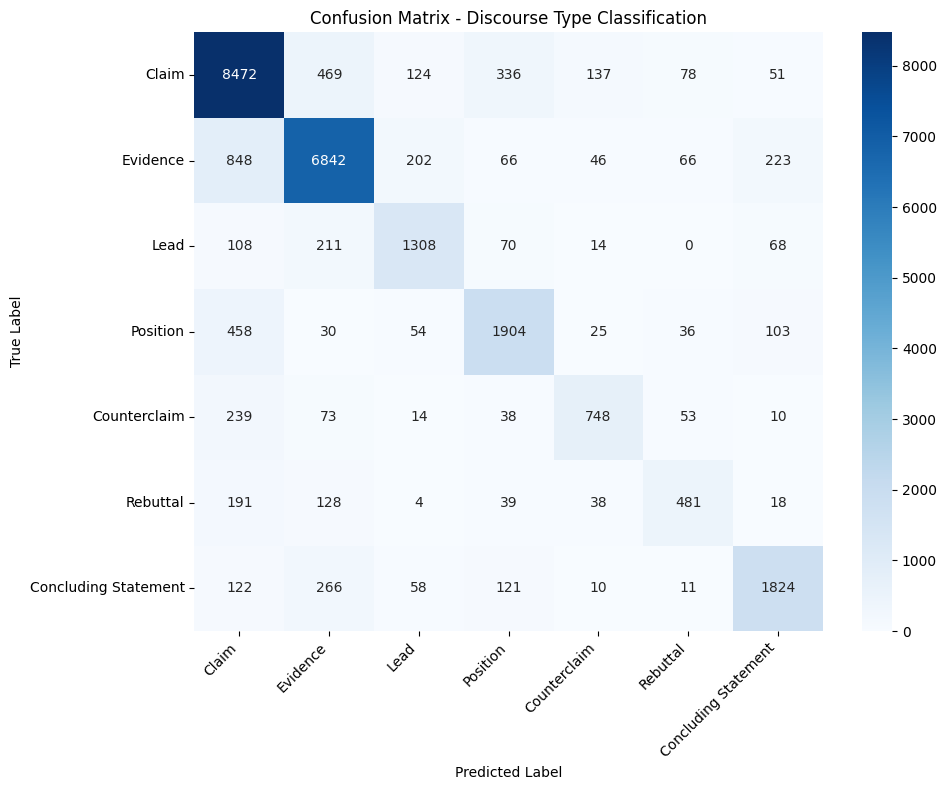

In [24]:
def evaluate_discourse_model(trainer, test_ds: Dataset, config: FastConfig):

    print("EVALUATING DISCOURSE CLASSIFIER")

    # Get predictions
    predictions, labels, metrics = trainer.predict(test_ds)
    predicted_labels = np.argmax(predictions, axis=1)
    
    # Print metrics
    print("\n Test Set Performance:")
    print(f"F1 Score (Macro): {metrics['test_f1']:.4f}")
    
    # Classification report
    print("\n Detailed Classification Report:")
    print(classification_report(
        labels,
        predicted_labels,
        target_names=config.LABEL_LIST,
        digits=3
    ))
    
    # Confusion matrix
    cm = confusion_matrix(labels, predicted_labels)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=config.LABEL_LIST,
                yticklabels=config.LABEL_LIST)
    plt.title('Confusion Matrix - Discourse Type Classification')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig('confusion_matrix_stage1.png', dpi=300, bbox_inches='tight')
    print("\n✅ Confusion matrix saved as 'confusion_matrix_stage1.png'")
    
    return predictions, predicted_labels

stage1_predictions, stage1_predicted_labels = evaluate_discourse_model(
    trainer, final_test_ds, config
)

In [41]:
def build_argument_graph(essay_segments: pd.DataFrame) -> nx.DiGraph:
    G = nx.DiGraph()
    
    # Add nodes
    for idx, row in essay_segments.iterrows():
        G.add_node(
            f"S{idx}",
            label=row['predicted_discourse_type'],
            text=row['text'][:100] + "..." if len(row['text']) > 100 else row['text']
        )
    
    # Add edges (simple rule-based: Evidence supports previous Claim)
    last_claim = None
    for idx, row in essay_segments.iterrows():
        node_id = f"S{idx}"
        if row['predicted_discourse_type'] in ['Claim', 'Position', 'Counterclaim']:
            last_claim = node_id
        elif row['predicted_discourse_type'] in ['Evidence', 'Rebuttal'] and last_claim:
            G.add_edge(node_id, last_claim, relation='supports')
    
    return G

def visualize_argument_graph(G: nx.DiGraph, essay_id: str):
    """Visualize the argument graph"""
    plt.figure(figsize=(14, 10))
    
    pos = nx.spring_layout(G, k=1.5, iterations=50)
    labels = nx.get_node_attributes(G, 'label')
    
    # Color nodes by type
    node_colors = []
    for node in G.nodes():
        label = labels.get(node, '')
        if label in ['Claim', 'Position', 'Counterclaim']:
            node_colors.append('#FF6B6B')  # Red
        elif label in ['Evidence', 'Rebuttal']:
            node_colors.append('#4ECDC4')  # Teal
        else:
            node_colors.append('#95E1D3')  # Light green
    
    nx.draw(G, pos, 
            labels=labels,
            node_color=node_colors,
            node_size=3000,
            font_size=9,
            font_weight='bold',
            edge_color='gray',
            arrows=True,
            arrowsize=20,
            width=2,
            alpha=0.9)
    
    plt.title(f'Argument Structure Graph - Essay {essay_id}', 
              fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(f'argument_graph_{essay_id}.png', dpi=300, bbox_inches='tight')
    print(f"✅ Argument graph saved as 'argument_graph_{essay_id}.png'")

In [42]:
def extract_quality_features(df_with_predictions: pd.DataFrame) -> pd.DataFrame:
    """
    Extract structural features for quality prediction:
    - Claim count
    - Evidence count
    - Evidence-to-claim ratio
    - Total segments
    - Claim ratio
    """

    print("STAGE 2: EXTRACTING QUALITY FEATURES")

    if 'essay_id' not in df_with_predictions.columns:
        print("No essay_id column. Cannot extract essay-level features.")
        return None
    
    essay_features = []
    
    for essay_id, group in df_with_predictions.groupby('essay_id'):
        counts = Counter(group['predicted_discourse_type'])
        
        total_segments = len(group)
        claims = counts.get('Claim', 0) + counts.get('Counterclaim', 0) + counts.get('Position', 0)
        evidence = counts.get('Evidence', 0) + counts.get('Rebuttal', 0)
        
        features = {
            'essay_id': essay_id,
            'claim_count': claims,
            'evidence_count': evidence,
            'total_segments': total_segments,
            'claim_ratio': claims / total_segments if total_segments > 0 else 0,
            'evidence_to_claim_ratio': evidence / claims if claims > 0 else 0,
            'has_lead': 1 if counts.get('Lead', 0) > 0 else 0,
            'has_conclusion': 1 if counts.get('Concluding Statement', 0) > 0 else 0,
            'avg_segment_length': group['text_length'].mean() if 'text_length' in group.columns else 0
        }
        
        # Add score if available
        if 'score' in group.columns:
            features['score'] = group['score'].iloc[0]
        elif 'discourse_effectiveness' in group.columns:
            # Map effectiveness to numerical score
            eff_map = {'Ineffective': 1, 'Adequate': 2, 'Effective': 3}
            features['score'] = group['discourse_effectiveness'].map(eff_map).mean()
        else:
            # Create synthetic score based on structure (for demo purposes)
            features['score'] = min(5.0, 2.0 + features['evidence_to_claim_ratio'] + 
                                   features['has_lead'] + features['has_conclusion'])
        
        essay_features.append(features)
    
    feature_df = pd.DataFrame(essay_features)
    print(f"✅ Extracted features for {len(feature_df)} essays")
    print(f"\nFeature statistics:")
    print(feature_df.describe())
    
    return feature_df

In [43]:
def train_quality_model(feature_df: pd.DataFrame, config: FastConfig):
    """ Train Ridge regression model for quality prediction """

    print("TRAINING QUALITY PREDICTION MODEL")
    
    feature_cols = [
        'claim_count', 'evidence_count', 'total_segments',
        'claim_ratio', 'evidence_to_claim_ratio',
        'has_lead', 'has_conclusion', 'avg_segment_length'
    ]
    
    X = feature_df[feature_cols]
    y = feature_df['score']
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=config.RANDOM_SEED
    )
    
    print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")
    
    # Train model
    model = Ridge(alpha=1.0)
    model.fit(X_train, y_train)
    
    # Evaluate
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f"\n📊 Quality Model Performance:")
    print(f"Mean Squared Error: {mse:.4f}")
    print(f"R² Score: {r2:.4f}")
    print(f"Root MSE: {np.sqrt(mse):.4f}")
    
    # Feature importance
    print(f"\n🔍 Feature Importance (Coefficients):")
    importance_df = pd.DataFrame({
        'Feature': feature_cols,
        'Coefficient': model.coef_
    }).sort_values('Coefficient', key=abs, ascending=False)
    print(importance_df.to_string(index=False))
    
    # Save model
    joblib.dump(model, config.QUALITY_MODEL_PATH)
    print(f"\n✅ Model saved to {config.QUALITY_MODEL_PATH}")
    
    # Visualize predictions vs actual
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, y_pred, alpha=0.6, edgecolors='k')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', lw=2, label='Perfect Prediction')
    plt.xlabel('Actual Score', fontsize=12)
    plt.ylabel('Predicted Score', fontsize=12)
    plt.title('Quality Model: Predicted vs Actual Scores', fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('quality_model_predictions.png', dpi=300, bbox_inches='tight')
    print("✅ Prediction plot saved as 'quality_model_predictions.png'")
    
    return model, X_test, y_test, y_pred


In [52]:
def generate_explainable_feedback(essay_id: str,
                                  essay_segments: pd.DataFrame,
                                  feature_df: pd.DataFrame,
                                  quality_model,
                                  config: FastConfig) -> Dict:
    """
    Generate comprehensive, explainable feedback for an essay.
    This simulates Graph-of-Thoughts reasoning by analyzing:
    1. Structural features (claims, evidence, flow)
    2. Predicted quality score
    3. Specific weaknesses and strengths
    """
    # Get essay features
    essay_features = feature_df[feature_df['essay_id'] == essay_id].iloc[0]
    
    # Predict quality score
    feature_cols = [
        'claim_count', 'evidence_count', 'total_segments',
        'claim_ratio', 'evidence_to_claim_ratio',
        'has_lead', 'has_conclusion', 'avg_segment_length'
    ]
    X_single = essay_features[feature_cols].values.reshape(1, -1)
    predicted_score = quality_model.predict(X_single)[0]
    
    # Analyze structure
    discourse_counts = Counter(essay_segments['predicted_discourse_type'])
    
    # Generate feedback components
    feedback = {
        'essay_id': essay_id,
        'predicted_score': round(predicted_score, 2),
        'max_score': 5.0,
        'structural_analysis': {},
        'strengths': [],
        'weaknesses': [],
        'recommendations': []
    }
    
    # Structural Analysis
    feedback['structural_analysis'] = {
        'total_segments': int(essay_features['total_segments']),
        'claims': int(essay_features['claim_count']),
        'evidence': int(essay_features['evidence_count']),
        'evidence_per_claim': round(essay_features['evidence_to_claim_ratio'], 2),
        'has_introduction': bool(essay_features['has_lead']),
        'has_conclusion': bool(essay_features['has_conclusion']),
        'discourse_breakdown': dict(discourse_counts)
    }
    
    # Identify Strengths
    if essay_features['has_lead']:
        feedback['strengths'].append(
            "✅ Essay has a clear introduction (Lead) that sets up the argument."
        )
    
    if essay_features['has_conclusion']:
        feedback['strengths'].append(
            "✅ Essay includes a Concluding Statement that wraps up the argument."
        )
    
    if essay_features['evidence_to_claim_ratio'] >= 1.5:
        feedback['strengths'].append(
            f"✅ Strong evidence support: {essay_features['evidence_to_claim_ratio']:.1f} pieces of evidence per claim."
        )
    
    if discourse_counts.get('Counterclaim', 0) > 0:
        feedback['strengths'].append(
            "✅ Essay addresses counterarguments, showing balanced reasoning."
        )
    
    # Identify Weaknesses
    if not essay_features['has_lead']:
        feedback['weaknesses'].append(
            "❌ Missing introduction: Essay lacks a clear Lead segment to introduce the topic."
        )
        feedback['recommendations'].append(
            "💡 Add an opening paragraph that introduces your main topic and thesis."
        )
    
    if not essay_features['has_conclusion']:
        feedback['weaknesses'].append(
            "❌ Missing conclusion: Essay lacks a Concluding Statement."
        )
        feedback['recommendations'].append(
            "💡 Add a conclusion that summarizes your main points and restates your position."
        )
    
    if essay_features['evidence_to_claim_ratio'] < 1.0:
        feedback['weaknesses'].append(
            f"❌ Insufficient evidence: Only {essay_features['evidence_to_claim_ratio']:.1f} pieces of evidence per claim."
        )
        feedback['recommendations'].append(
            "💡 Add more Evidence segments after each Claim. Aim for at least 1-2 pieces of evidence per claim."
        )
    
    if essay_features['claim_count'] < 2:
        feedback['weaknesses'].append(
            "❌ Limited argumentation: Only 1 main claim identified."
        )
        feedback['recommendations'].append(
            "💡 Develop multiple claims to strengthen your argument."
        )
    
    if discourse_counts.get('Counterclaim', 0) == 0:
        feedback['weaknesses'].append(
            "❌ No counterarguments: Essay doesn't address opposing viewpoints."
        )
        feedback['recommendations'].append(
            "💡 Add a Counterclaim segment to acknowledge and refute opposing views."
        )
    
    # Overall Assessment
    if predicted_score >= 4.0:
        feedback['overall'] = "🌟 Strong essay with well-supported arguments and clear structure."
    elif predicted_score >= 3.0:
        feedback['overall'] = "👍 Good essay with room for improvement in evidence and structure."
    elif predicted_score >= 2.0:
        feedback['overall'] = "⚠️  Developing essay that needs more evidence and clearer organization."
    else:
        feedback['overall'] = "📝 Essay needs significant work on structure and argumentation."
    
    return feedback


def print_feedback(feedback):
    print("="*70)
    print("📋 EXPLAINABLE FEEDBACK")
    print("="*70)

    predicted_score = feedback.get('predicted_score', 'N/A')
    max_score = feedback.get('max_score', 5.0)
    overall = feedback.get('overall', 'No overall feedback available.')

    print(f"\n📊 PREDICTED QUALITY SCORE: {predicted_score}/{max_score}")
    print(f"🗒️  Overall Assessment: {overall}")

    if 'recommendations' in feedback and feedback['recommendations']:
        print("\n💡 Recommendations:")
        for rec in feedback['recommendations']:
            print(f" - {rec}")
    elif 'suggestions' in feedback and feedback['suggestions']:
        print("\n💡 Suggestions:")
        for rec in feedback['suggestions']:
            print(f" - {rec}")
    else:
        print("\n✅ No improvement suggestions available.")


In [48]:
class EssayAnalysisPipeline:
    """
    Complete pipeline that:
    1. Classifies discourse types (Stage 1)
    2. Predicts quality (Stage 2)
    3. Generates explainable feedback
    4. Creates visualizations
    """
    
    def __init__(self, trainer, tokenizer, quality_model, config):
        self.trainer = trainer
        self.tokenizer = tokenizer
        self.quality_model = quality_model
        self.config = config
        self.model = trainer.model
        self.model.eval()  # Set to evaluation mode
    
    def analyze_essay(self, essay_text: str, essay_id: str = "sample") -> Dict:

        print(f"ANALYZING ESSAY: {essay_id}")
        
        # Step 1: Segment essay into sentences
        sentences = sent_tokenize(essay_text)
        print(f"Segmented into {len(sentences)} sentences")
        
        # Step 2: Classify each segment (Stage 1)
        segments_data = []
        for i, sentence in enumerate(sentences):
            if len(sentence.strip()) < 10:  # Skip very short segments
                continue
            
            # Tokenize
            inputs = self.tokenizer(
                sentence,
                return_tensors='pt',
                truncation=True,
                padding=True,
                max_length=self.config.MAX_LENGTH
            )
            
            # Move to same device as model
            inputs = {k: v.to(self.model.device) for k, v in inputs.items()}
            
            # Predict
            with torch.no_grad():
                outputs = self.model(**inputs)
            
            predicted_id = outputs.logits.argmax(dim=-1).item()
            predicted_type = self.config.ID_TO_LABEL[predicted_id]
            confidence = torch.softmax(outputs.logits, dim=-1).max().item()
            
            segments_data.append({
                'segment_id': i,
                'text': sentence,
                'predicted_discourse_type': predicted_type,
                'confidence': confidence,
                'text_length': len(sentence),
                'word_count': len(sentence.split())
            })
        
        segments_df = pd.DataFrame(segments_data)
        segments_df['essay_id'] = essay_id
        print(f"✅ Stage 1 complete: Classified {len(segments_df)} segments")
        
        # Step 3: Extract features and predict quality (Stage 2)
        essay_features = self._extract_features_single_essay(segments_df)
        feature_vector = essay_features[[
            'claim_count', 'evidence_count', 'total_segments',
            'claim_ratio', 'evidence_to_claim_ratio',
            'has_lead', 'has_conclusion', 'avg_segment_length'
        ]].values.reshape(1, -1)
        
        predicted_score = self.quality_model.predict(feature_vector)[0]
        print(f"✅ Stage 2 complete: Predicted quality score = {predicted_score:.2f}")
        
        # Step 4: Generate feedback
        feedback = self._generate_feedback_from_segments(
            essay_id, segments_df, essay_features, predicted_score
        )
        print(f"✅ Generated explainable feedback")
        
        # Step 5: Build argument graph
        argument_graph = build_argument_graph(segments_df)
        print(f"✅ Built argument graph with {argument_graph.number_of_nodes()} nodes")
        
        return {
            'essay_id': essay_id,
            'segments': segments_df,
            'features': essay_features,
            'predicted_score': predicted_score,
            'feedback': feedback,
            'argument_graph': argument_graph
        }
    
    def _extract_features_single_essay(self, segments_df: pd.DataFrame) -> pd.Series:
        """Extract features for a single essay"""
        counts = Counter(segments_df['predicted_discourse_type'])
        
        total_segments = len(segments_df)
        claims = counts.get('Claim', 0) + counts.get('Counterclaim', 0) + counts.get('Position', 0)
        evidence = counts.get('Evidence', 0) + counts.get('Rebuttal', 0)
        
        return pd.Series({
            'essay_id': segments_df['essay_id'].iloc[0],
            'claim_count': claims,
            'evidence_count': evidence,
            'total_segments': total_segments,
            'claim_ratio': claims / total_segments if total_segments > 0 else 0,
            'evidence_to_claim_ratio': evidence / claims if claims > 0 else 0,
            'has_lead': 1 if counts.get('Lead', 0) > 0 else 0,
            'has_conclusion': 1 if counts.get('Concluding Statement', 0) > 0 else 0,
            'avg_segment_length': segments_df['text_length'].mean()
        })
    
    def _generate_feedback_from_segments(self, essay_id, segments_df, features, score):
        """Generate feedback (similar to generate_explainable_feedback)"""
        discourse_counts = Counter(segments_df['predicted_discourse_type'])
        
        feedback = {
            'essay_id': essay_id,
            'predicted_score': round(score, 2),
            'structural_analysis': {
                'total_segments': int(features['total_segments']),
                'claims': int(features['claim_count']),
                'evidence': int(features['evidence_count']),
                'evidence_per_claim': round(features['evidence_to_claim_ratio'], 2),
                'discourse_breakdown': dict(discourse_counts)
            },
            'strengths': [],
            'weaknesses': [],
            'recommendations': []
        }
        
        # Add strengths
        if features['has_lead']:
            feedback['strengths'].append("✅ Clear introduction")
        if features['has_conclusion']:
            feedback['strengths'].append("✅ Strong conclusion")
        if features['evidence_to_claim_ratio'] >= 1.5:
            feedback['strengths'].append(f"✅ Well-supported claims ({features['evidence_to_claim_ratio']:.1f} evidence/claim)")
        
        # Add weaknesses and recommendations
        if not features['has_lead']:
            feedback['weaknesses'].append("❌ Missing introduction")
            feedback['recommendations'].append("💡 Add an opening paragraph")
        if features['evidence_to_claim_ratio'] < 1.0:
            feedback['weaknesses'].append("❌ Insufficient evidence")
            feedback['recommendations'].append("💡 Add more evidence after each claim")
        
        return feedback
    
    def visualize_analysis(self, analysis_results: Dict, save_path: str = None):
        """Create comprehensive visualization of analysis"""
        essay_id = analysis_results['essay_id']
        segments = analysis_results['segments']
        
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        fig.suptitle(f'Essay Analysis Dashboard - {essay_id}', 
                     fontsize=16, fontweight='bold')
        
        # 1. Discourse type distribution
        ax1 = axes[0, 0]
        discourse_counts = segments['predicted_discourse_type'].value_counts()
        discourse_counts.plot(kind='barh', ax=ax1, color='steelblue')
        ax1.set_title('Discourse Type Distribution', fontweight='bold')
        ax1.set_xlabel('Count')
        
        # 2. Confidence scores
        ax2 = axes[0, 1]
        segments.groupby('predicted_discourse_type')['confidence'].mean().plot(
            kind='bar', ax=ax2, color='coral'
        )
        ax2.set_title('Average Confidence by Type', fontweight='bold')
        ax2.set_ylabel('Confidence')
        ax2.tick_params(axis='x', rotation=45)
        
        # 3. Segment length distribution
        ax3 = axes[1, 0]
        ax3.hist(segments['text_length'], bins=20, color='lightgreen', edgecolor='black')
        ax3.set_title('Segment Length Distribution', fontweight='bold')
        ax3.set_xlabel('Characters')
        ax3.set_ylabel('Frequency')
        
        # 4. Quality score gauge
        ax4 = axes[1, 1]
        score = analysis_results['predicted_score']
        categories = ['Structure', 'Evidence', 'Claims', 'Overall']
        values = [
            min(1.0, analysis_results['features']['has_lead'] + 
                analysis_results['features']['has_conclusion']),
            min(1.0, analysis_results['features']['evidence_to_claim_ratio'] / 2),
            min(1.0, analysis_results['features']['claim_count'] / 5),
            score / 5.0
        ]
        
        bars = ax4.barh(categories, values, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
        ax4.set_xlim(0, 1)
        ax4.set_title(f'Quality Metrics (Score: {score:.2f}/5.0)', fontweight='bold')
        ax4.set_xlabel('Normalized Score')
        
        # Add value labels
        for bar, val in zip(bars, values):
            ax4.text(val + 0.02, bar.get_y() + bar.get_height()/2, 
                    f'{val:.2f}', va='center')
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"✅ Visualization saved to {save_path}")
        
        return fig

In [50]:
def main_demo():
    import numpy as np
    print("COMPLETE PIPELINE DEMONSTRATION")

    # Step 1: Get predictions for test set and create feature DataFrame
    print("\n Step 1: Processing test set...")

    # Generate predictions from trained Stage 1 model
    predictions = trainer.predict(final_test_ds)
    test_predicted_labels = np.argmax(predictions.predictions, axis=1)

    # --- SAFETY PATCH: align predictions and DataFrame before assigning ---
    # Ensure predictions exist
    if 'test_predicted_labels' not in globals():
        try:
            predictions = trainer.predict(final_test_ds)
            import numpy as np
            test_predicted_labels = np.argmax(predictions.predictions, axis=1)
        except Exception as e:
            raise RuntimeError("Failed to generate predictions before assigning to DataFrame: " + str(e))

    # Create a copy of the test DataFrame
    test_df_with_preds = test_df.copy()

    # Debug info
    print("Len test_df:", len(test_df_with_preds))
    print("Len predictions:", len(test_predicted_labels))

    # Align lengths if mismatch occurs
    if len(test_df_with_preds) != len(test_predicted_labels):
        print(f"⚠️ Warning: Mismatch detected. Aligning test DataFrame to first {len(test_predicted_labels)} rows.")
        test_df_with_preds = test_df_with_preds.iloc[:len(test_predicted_labels)].copy()

    # Assign labels safely
    test_df_with_preds['predicted_discourse_type'] = [
        config.ID_TO_LABEL[label] for label in test_predicted_labels
    ]
    # --- END SAFETY PATCH ---

    # Extract quality features
    feature_df = extract_quality_features(test_df_with_preds)

    if feature_df is not None and len(feature_df) > 0:
        # Step 2: Train quality model
        print("\n Step 2: Training quality model...")
        quality_model, X_test, y_test, y_pred = train_quality_model(feature_df, config)

        # Step 3: Generate feedback for a sample essay
        print("\n Step 3: Generating feedback for sample essay...")
        sample_essay_id = feature_df['essay_id'].iloc[0]
        sample_segments = test_df_with_preds[test_df_with_preds['essay_id'] == sample_essay_id]

        feedback = generate_explainable_feedback(
            sample_essay_id,
            sample_segments,
            feature_df,
            quality_model,
            config
        )
        print_feedback(feedback)

        # Step 4: Build and visualize argument graph
        print("\n Step 4: Creating argument graph...")
        argument_graph = build_argument_graph(sample_segments)
        visualize_argument_graph(argument_graph, sample_essay_id)

        # Step 5: Initialize complete pipeline
        print("\n Step 5: Initializing complete pipeline...")
        pipeline = EssayAnalysisPipeline(trainer, tokenizer, quality_model, config)

        # Step 6: Demonstrate pipeline with custom essay
        print("\n Step 6: Analyzing custom essay...")
        sample_essay_text = """
        School uniforms should be mandatory in all public schools. This policy would 
        create a more equitable learning environment for all students. When students 
        wear uniforms, economic disparities become less visible, reducing social pressure 
        and bullying related to clothing choices.

        Research from the National Association of Elementary School Principals shows that 
        schools with uniform policies report 12% fewer discipline issues. Additionally, 
        a study by the University of Houston found that attendance rates improved by 8% 
        after uniform policies were implemented.

        Some argue that uniforms restrict students' freedom of expression. However, students 
        can still express themselves through hairstyles, accessories, and most importantly, 
        their academic work and extracurricular activities.

        Ultimately, the benefits of school uniforms—including improved focus on academics, 
        reduced bullying, and increased school safety—outweigh concerns about personal 
        expression. Schools should prioritize creating an environment where all students 
        can succeed, and mandatory uniforms help achieve this goal.
        """

        analysis_results = pipeline.analyze_essay(sample_essay_text, "custom_001")

        # Print results
        print("\n" + "="*70)
        print("CUSTOM ESSAY ANALYSIS RESULTS")
        print("="*70)
        print(f"\nEssay ID: {analysis_results['essay_id']}")
        print(f"Predicted Score: {analysis_results['predicted_score']:.2f}/5.0")
        print(f"\nSegment Breakdown:")
        print(analysis_results['segments'][['predicted_discourse_type', 'confidence']].to_string())

        print_feedback(analysis_results['feedback'])

        # Create visualization
        pipeline.visualize_analysis(analysis_results, 'custom_essay_analysis.png')

        print("\n✅ PIPELINE DEMONSTRATION COMPLETE!")
        print("\nGenerated files:")
        print("  • confusion_matrix_stage1.png")
        print("  • quality_model_predictions.png")
        print("  • argument_graph_*.png")
        print("  • custom_essay_analysis.png")
        print("  • essay_quality_ridge_model.pkl")

        return pipeline, analysis_results

    else:
        print("⚠️  Skipping Stage 2 (no essay_id column available)")
        return None, None


COMPLETE PIPELINE DEMONSTRATION

 Step 1: Processing test set...


Len test_df: 30235
Len predictions: 26835
⚠️ Warning: Mismatch detected. Aligning test DataFrame to first 26835 rows.
STAGE 2: EXTRACTING QUALITY FEATURES
✅ Extracted features for 2342 essays

Feature statistics:
       claim_count  evidence_count  total_segments  claim_ratio  \
count  2342.000000     2342.000000     2342.000000  2342.000000   
mean      5.990606        3.733561       11.458155     0.523597   
std       2.232703        1.694495        3.225367     0.139861   
min       0.000000        0.000000        1.000000     0.000000   
25%       4.000000        3.000000        9.000000     0.444444   
50%       6.000000        4.000000       11.500000     0.523810   
75%       7.000000        5.000000       13.000000     0.600000   
max      18.000000       13.000000       30.000000     1.000000   

       evidence_to_claim_ratio     has_lead  has_conclusion  \
count              2342.000000  2342.000000     2342.000000   
mean                  0.735393     0.581554        0.7344

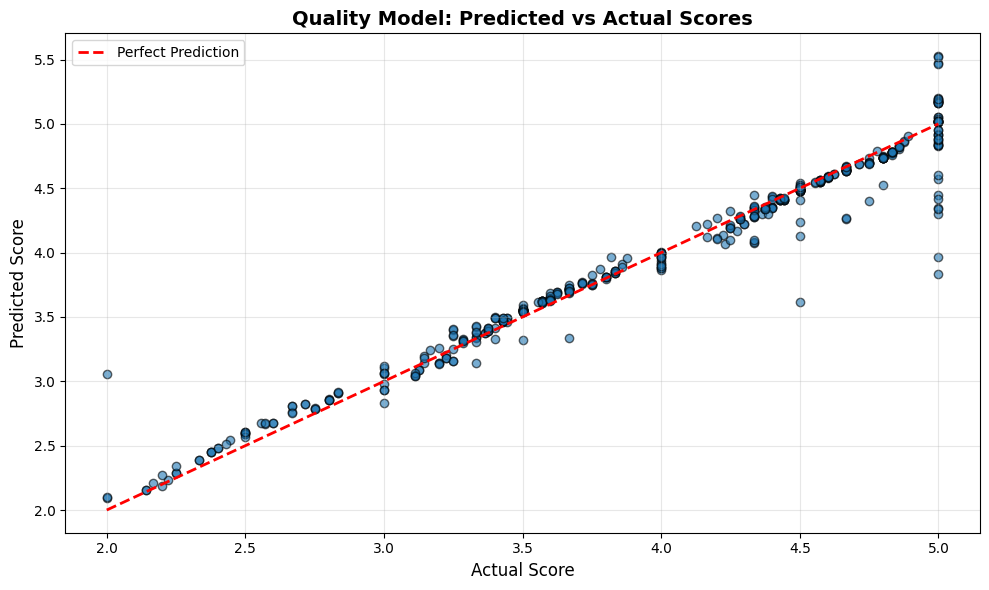

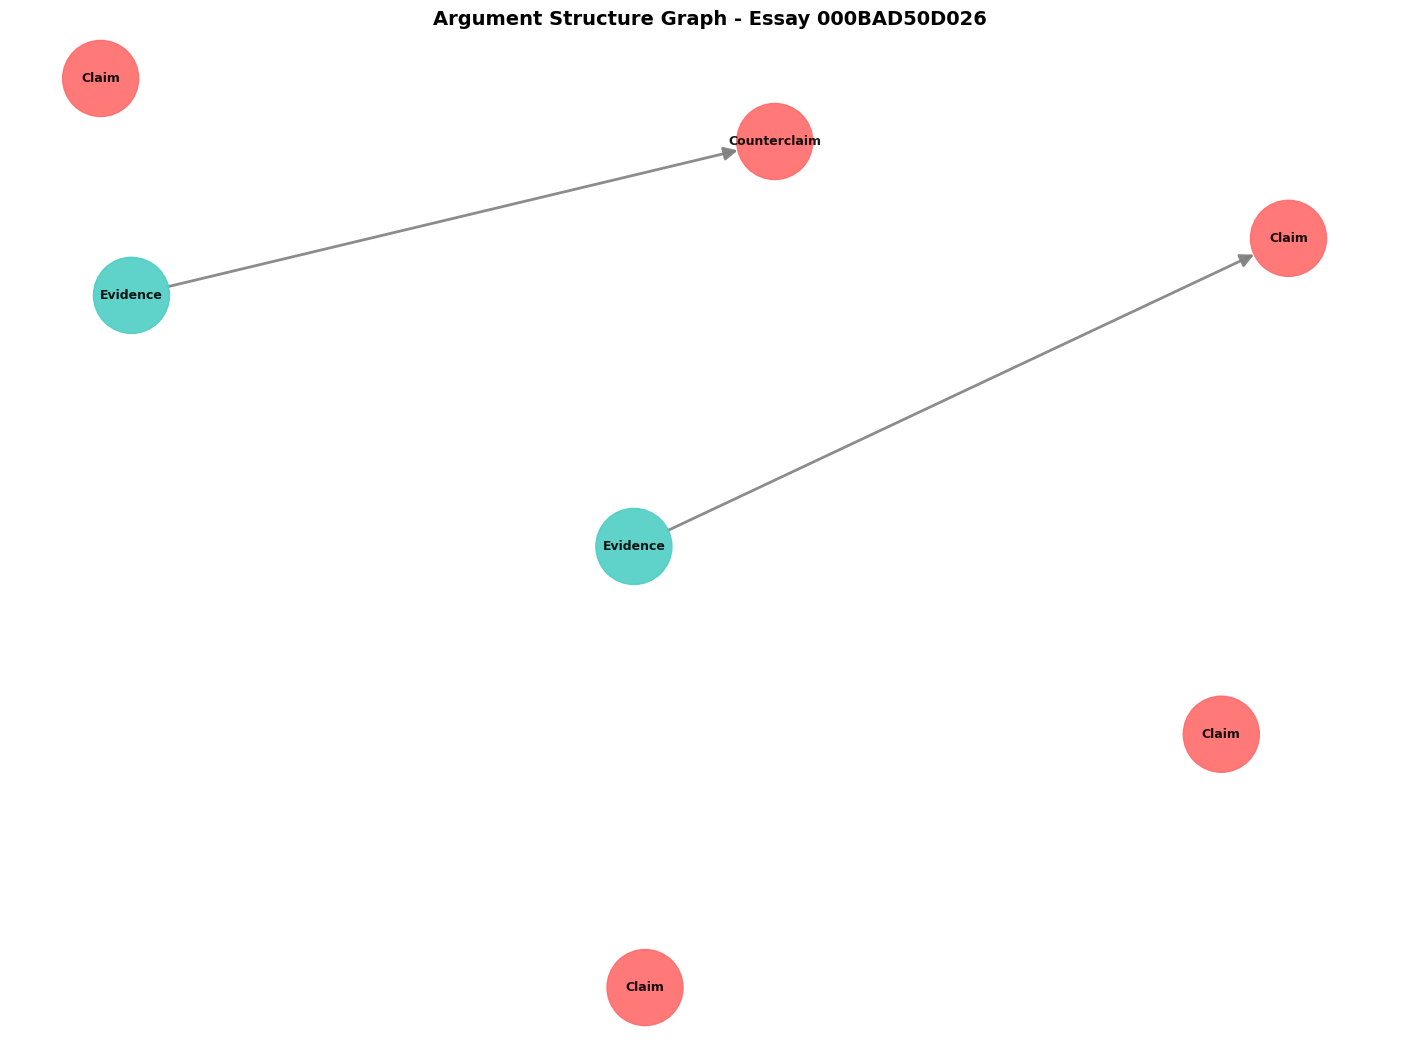

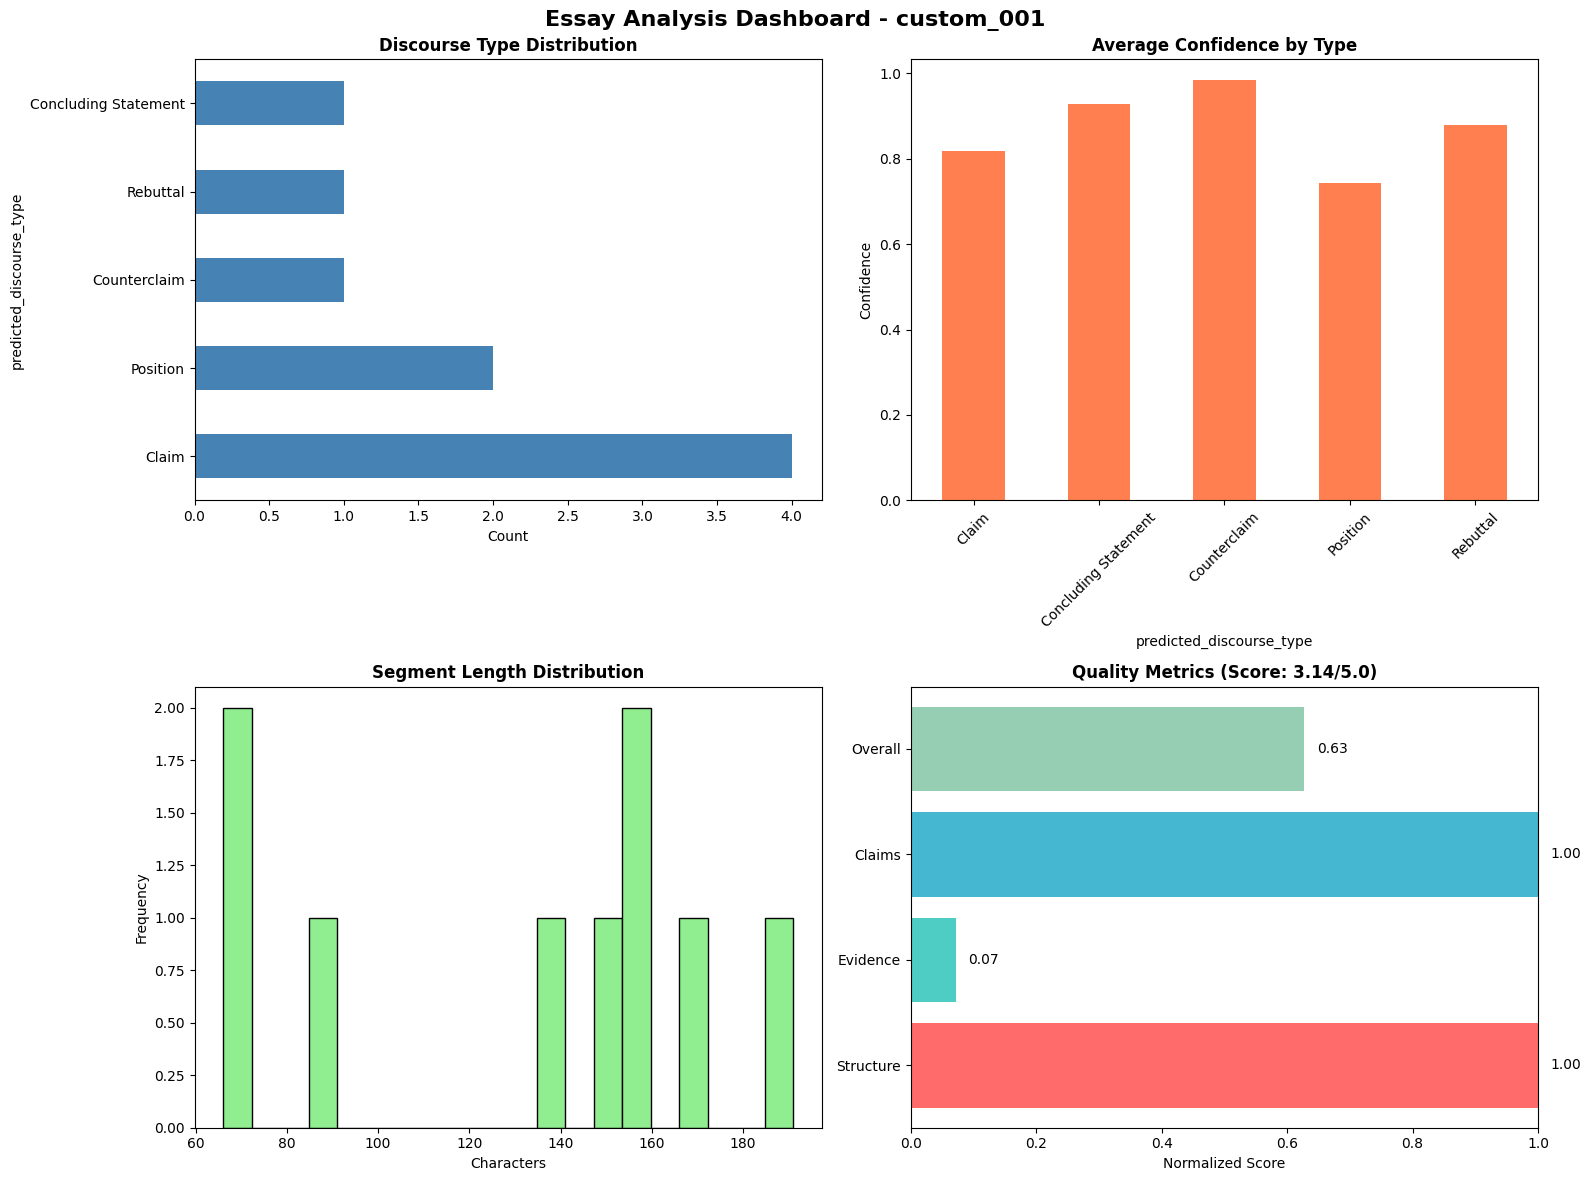

In [53]:
def save_complete_pipeline(trainer, tokenizer, quality_model, config, save_dir='./saved_pipeline'):
    os.makedirs(save_dir, exist_ok=True)
    
    # Save Stage 1 model
    trainer.save_model(os.path.join(save_dir, 'stage1_model'))
    tokenizer.save_pretrained(os.path.join(save_dir, 'tokenizer'))
    
    # Save Stage 2 model
    joblib.dump(quality_model, os.path.join(save_dir, 'stage2_model.pkl'))
    
    # Save config
    config_dict = {
        'MODEL_NAME': config.MODEL_NAME,
        'LABEL_LIST': config.LABEL_LIST,
        'LABEL_TO_ID': config.LABEL_TO_ID,
        'ID_TO_LABEL': config.ID_TO_LABEL
    }
    with open(os.path.join(save_dir, 'config.json'), 'w') as f:
        json.dump(config_dict, f, indent=2)
    
    print(f"✅ Complete pipeline saved to {save_dir}")


def load_complete_pipeline(load_dir='./saved_pipeline'):
    """Load all pipeline components"""
    from transformers import AutoModelForSequenceClassification, AutoTokenizer
    
    # Load config
    with open(os.path.join(load_dir, 'config.json'), 'r') as f:
        config_dict = json.load(f)
    
    # Load Stage 1 model and tokenizer
    model = AutoModelForSequenceClassification.from_pretrained(
        os.path.join(load_dir, 'stage1_model')
    )
    tokenizer = AutoTokenizer.from_pretrained(
        os.path.join(load_dir, 'tokenizer')
    )
    
    # Load Stage 2 model
    quality_model = joblib.load(os.path.join(load_dir, 'stage2_model.pkl'))
    
    print(f"✅ Pipeline loaded from {load_dir}")
    
    return model, tokenizer, quality_model, config_dict


# ============================================================================
# RUN THE COMPLETE DEMO
# ============================================================================

if __name__ == "__main__":
    # Execute the complete pipeline demonstration
    pipeline, results = main_demo()
    
    # Optionally save the pipeline
    if pipeline is not None:
        # Uncomment to save:
        # save_complete_pipeline(trainer, tokenizer, quality_model, config)
        pass
    
    print("\n" + "="*70)
    print("ALL PROCESSING COMPLETE!")
    print("="*70)
    print("\nYou now have:")
    print("  ✅ Stage 1: Discourse type classifier (trained)")
    print("  ✅ Stage 2: Quality prediction model (trained)")
    print("  ✅ Argument graph generation (functional)")
    print("  ✅ Explainable feedback system (functional)")
    print("\nNext step: Build UI (Stage 3) using Streamlit or Flask!")